# 16 — Attention Head Analysis

Per-head decomposition of what each attention head has learned, across the three
full-dataset attention checkpoints trained this summer at different head counts
(`heads2`, the `n_heads=4` champion, `heads8` — see the phase G head-count ablation).
Performance-wise the ablation already showed `n_heads=4` is the champion (best test
Pearson r); this notebook asks a different question — not "which head count wins,"
but "what does each head specialize in, and does that specialization change with
head count."

Reuses the existing per-element/per-residue attention-weight infrastructure in
`src/analysis/embedding_analysis.py` (`collect_attention_stats`,
`collect_attention_stats_residue`) rather than building new tooling — the same
functions `embedding_analysis.ipynb` (moved to `notebooks/`, one directory up)
already uses for a single checkpoint, extended here across three. Sections 8–9
layer the `PROTEININFO.md` research (side-chain classification, and
dataset-measured residue exposure) on top of that same per-residue data. Sections
11–12 flip the direction of that analysis: instead of imposing human groupings and
checking for agreement, they cluster residues from the raw attention data alone and
then test — quantitatively, not by eye — whether the emergent groups resemble any of
the human categories from sections 8–9, or nothing recognizable at all.

**Scope note:** this covers chemistry-level markers only (element identity,
residue identity, side-chain classification, and solvent exposure) — the kind of
"one head learns electronegative/acidic/exposed atoms" question. Structural/functional
markers like binding-pocket proximity are explicitly out of scope: no pocket-detection
data exists anywhere in this codebase (confirmed directly), and building that
annotation pipeline was already deferred ("that's for later").

## Sections
- **1** Configuration — the three checkpoints under comparison
- **2** Test performance comparison — Pearson r / RMSE / MAE per head-count config
- **3** Load all three checkpoints, collect per-element and per-residue attention stats
- **4** Per-element attention weight by head, one panel per head-count config
- **5** Per-residue attention weight heatmap, one panel per head-count config
- **6** Specialization score — does more heads mean sharper per-head differentiation?
- **7** Electronegativity-weighted head affinity
- **8** Attention weight by residue classification group (nonpolar/aromatic/polar/acidic/basic)
- **9** Attention weight by residue exposure group (buried-majority vs. exposed-majority)
- **11** Emergent residue groupings from attention alone — no chemistry labels used
- **12** Does the emergent grouping mean anything? — Adjusted Rand Index / NMI vs. sections 8–9
- **13** Decision

In [7]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

sys.path.insert(0, str(Path("../..").resolve()))

from src.analysis.embedding_analysis import (
    ELEMENT_NAMES,
    RESIDUE_NAMES,
    collect_attention_stats,
    collect_attention_stats_residue,
    load_model_frozen,
)
from src.data.dataset import load_split_manifest
from src.utils.config import get_data_root

import torch


## 1. Configuration

Three full-dataset attention checkpoints, differing only in `n_heads`. All other
architecture/training hyperparameters are identical (see `sweeps/phase_g_head_ablation.yaml`).

In [8]:
THESIS_ROOT = Path("/home/student/thesis")
CKPT_ROOT   = THESIS_ROOT / "checkpoints" / "full_dataset"

DEVICE    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DATA_ROOT = get_data_root()

CONFIGS = [
    (2, CKPT_ROOT / "attention_heads2"),
    (4, CKPT_ROOT / "attention_aa4_aq2_qq16"),   # champion, n_heads=4
    (8, CKPT_ROOT / "attention_heads8"),
]

for n_heads, ckpt_dir in CONFIGS:
    print(f"n_heads={n_heads}: {ckpt_dir}  (exists: {ckpt_dir.exists()})")


n_heads=2: /home/student/thesis/checkpoints/full_dataset/attention_heads2  (exists: True)
n_heads=4: /home/student/thesis/checkpoints/full_dataset/attention_aa4_aq2_qq16  (exists: True)
n_heads=8: /home/student/thesis/checkpoints/full_dataset/attention_heads8  (exists: True)


---
## 2. Test performance comparison

Global test-set metrics for each head-count checkpoint, read directly from each
`test_metrics.json` — the same numbers the phase G head-count ablation used to
pick `n_heads=4` as champion. Shown here as context before the per-head
interpretation below, so the attention-weight patterns can be read against a
concrete performance backdrop rather than in isolation.

,pearson_r,rmse,mae,n_proteins
n_heads,,,,
2,0.9327,2.0507,1.5067,848
4,0.9368,2.0422,1.5013,848
8,0.9347,2.0415,1.5018,848


INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


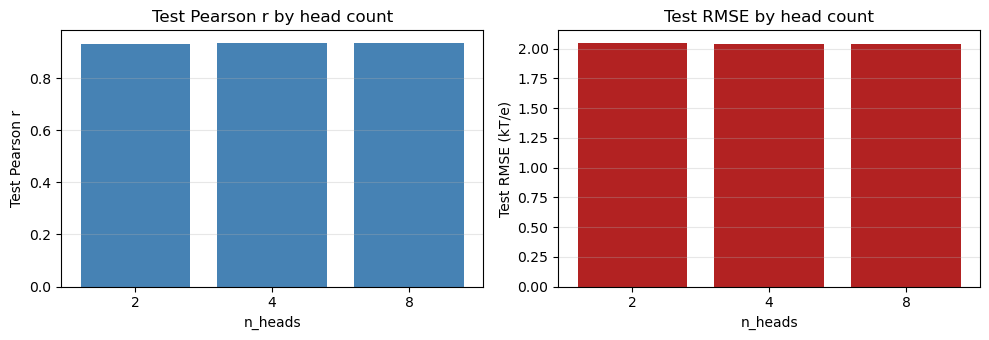

In [9]:
perf_rows = []
for n_heads, ckpt_dir in CONFIGS:
    metrics_path = ckpt_dir / "test_metrics.json"
    if not metrics_path.exists():
        print(f"n_heads={n_heads}: SKIP — {metrics_path} not found")
        continue
    with open(metrics_path) as f:
        g = json.load(f)["global"]
    perf_rows.append({
        "n_heads":    n_heads,
        "pearson_r":  g["pearson_r"],
        "rmse":       g["rmse"],
        "mae":        g["mae"],
        "n_proteins": g["n_proteins"],
    })

perf_df = pd.DataFrame(perf_rows).set_index("n_heads").round(4)
display(perf_df)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].bar([str(n) for n in perf_df.index], perf_df["pearson_r"], color="steelblue")
axes[0].set_xlabel("n_heads")
axes[0].set_ylabel("Test Pearson r")
axes[0].set_title("Test Pearson r by head count")
axes[0].grid(axis="y", alpha=0.3)

axes[1].bar([str(n) for n in perf_df.index], perf_df["rmse"], color="firebrick")
axes[1].set_xlabel("n_heads")
axes[1].set_ylabel("Test RMSE (kT/e)")
axes[1].set_title("Test RMSE by head count")
axes[1].grid(axis="y", alpha=0.3)

fig.tight_layout()
plt.show()


---
## 3. Load models & collect attention stats

One test-split pass per checkpoint (848 full-dataset test proteins), inference only —
no weights are modified. This is the expensive cell; results are cached in Python for
every section below.

In [10]:
_, _, test_ids = load_split_manifest(DATA_ROOT)
print(f"Collecting attention stats over {len(test_ids)} test proteins, {len(CONFIGS)} checkpoints...")

element_stats = {}   # n_heads -> {element_name: {"mean": [.]*n_heads, "std": [.]*n_heads, "count": int}}
residue_stats = {}   # n_heads -> {residue_name: {...}}

for n_heads, ckpt_dir in CONFIGS:
    if not ckpt_dir.exists():
        print(f"  SKIP n_heads={n_heads} — checkpoint not found")
        continue
    model, ckpt = load_model_frozen(ckpt_dir, DEVICE)
    print(f"  n_heads={n_heads}: loaded {ckpt['model_name']}, "
          f"parameters={sum(p.numel() for p in model.parameters()):,}")
    element_stats[n_heads] = collect_attention_stats(model, test_ids, DATA_ROOT, DEVICE)
    residue_stats[n_heads] = collect_attention_stats_residue(model, test_ids, DATA_ROOT, DEVICE)
    del model
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

print("Done.")


  n_heads=2: loaded attention, parameters=2,151,106
  n_heads=4: loaded attention, parameters=2,151,138
  n_heads=8: loaded attention, parameters=2,151,202
Done.


---
## 4. Per-element attention weight by head

Mean attention weight α per element per head. A flat distribution across elements
means a head attends by geometric proximity alone; systematic differentiation means
the head is using atom chemistry.

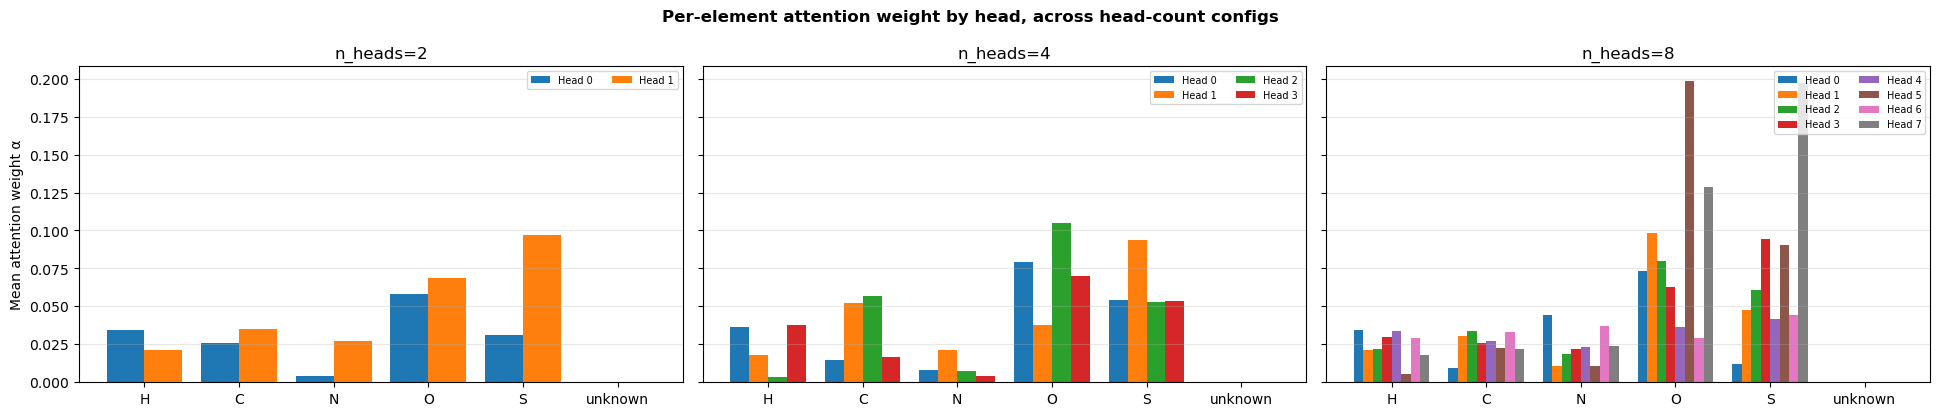

n_heads=2 — mean attention weight α by element


,Head 0,Head 1,count
H,0.0343,0.0215,44514850
C,0.0261,0.0350,29454533
N,0.0038,0.0272,8711890
O,0.0585,0.0684,9389893
S,0.0314,0.0968,167554
unknown,0.0000,0.0000,0


n_heads=4 — mean attention weight α by element


,Head 0,Head 1,Head 2,Head 3,count
H,0.0364,0.0178,0.0035,0.0377,44514850
C,0.0148,0.0523,0.0566,0.0169,29454533
N,0.0079,0.0210,0.0075,0.0041,8711890
O,0.0795,0.0376,0.1047,0.0703,9389893
S,0.0544,0.0939,0.0527,0.0538,167554
unknown,0.0000,0.0000,0.0000,0.0000,0


n_heads=8 — mean attention weight α by element


,Head 0,Head 1,Head 2,Head 3,Head 4,Head 5,Head 6,Head 7,count
H,0.0343,0.0214,0.0217,0.0297,0.0341,0.0055,0.0293,0.0179,44514850
C,0.0094,0.0306,0.0337,0.0260,0.0275,0.0227,0.0330,0.0216,29454533
N,0.0443,0.0107,0.0189,0.0222,0.0234,0.0106,0.0371,0.0241,8711890
O,0.0735,0.0985,0.0796,0.0625,0.0367,0.1982,0.0294,0.1284,9389893
S,0.0121,0.0477,0.0607,0.0944,0.0420,0.0901,0.0446,0.1971,167554
unknown,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0


In [11]:
available = [n for n, _ in CONFIGS if n in element_stats]

# "unknown" is kept even when its count is 0 — otherwise it silently drops out of
# the panel and looks indistinguishable from having been forgotten.
element_view = {}
for n_heads in available:
    stats = element_stats[n_heads]
    present = [(name, stats[name]) for name in ELEMENT_NAMES
               if stats[name]["count"] > 0 or name == "unknown"]
    element_view[n_heads] = {
        "names":  [p[0] for p in present],
        "means":  np.array([p[1]["mean"] for p in present]),   # (n_elem, n_heads)
        "counts": [p[1]["count"] for p in present],
    }

fig, axes = plt.subplots(1, len(available), figsize=(6.5 * len(available), 4.2), sharey=True)
if len(available) == 1:
    axes = [axes]

for ax, n_heads in zip(axes, available):
    names = element_view[n_heads]["names"]
    means = element_view[n_heads]["means"]

    x = np.arange(len(names))
    w = 0.8 / n_heads
    for h in range(n_heads):
        ax.bar(x + h * w - 0.4 + w / 2, means[:, h], width=w, label=f"Head {h}")
    ax.set_xticks(x)
    ax.set_xticklabels(names)
    ax.set_title(f"n_heads={n_heads}")
    ax.legend(loc="upper right", fontsize=7, ncol=2)
    ax.grid(axis="y", alpha=0.3)

axes[0].set_ylabel("Mean attention weight α")
fig.suptitle("Per-element attention weight by head, across head-count configs", fontweight="bold")
fig.tight_layout()
plt.show()

for n_heads in available:
    view = element_view[n_heads]
    df = pd.DataFrame(
        view["means"], index=view["names"],
        columns=[f"Head {h}" for h in range(n_heads)],
    ).round(4)
    df["count"] = view["counts"]
    print(f"n_heads={n_heads} — mean attention weight α by element")
    display(df)


---
## 5. Per-residue attention weight heatmap

Does the model attend differently depending on which amino acid an atom belongs to,
and does that pattern change with head count?

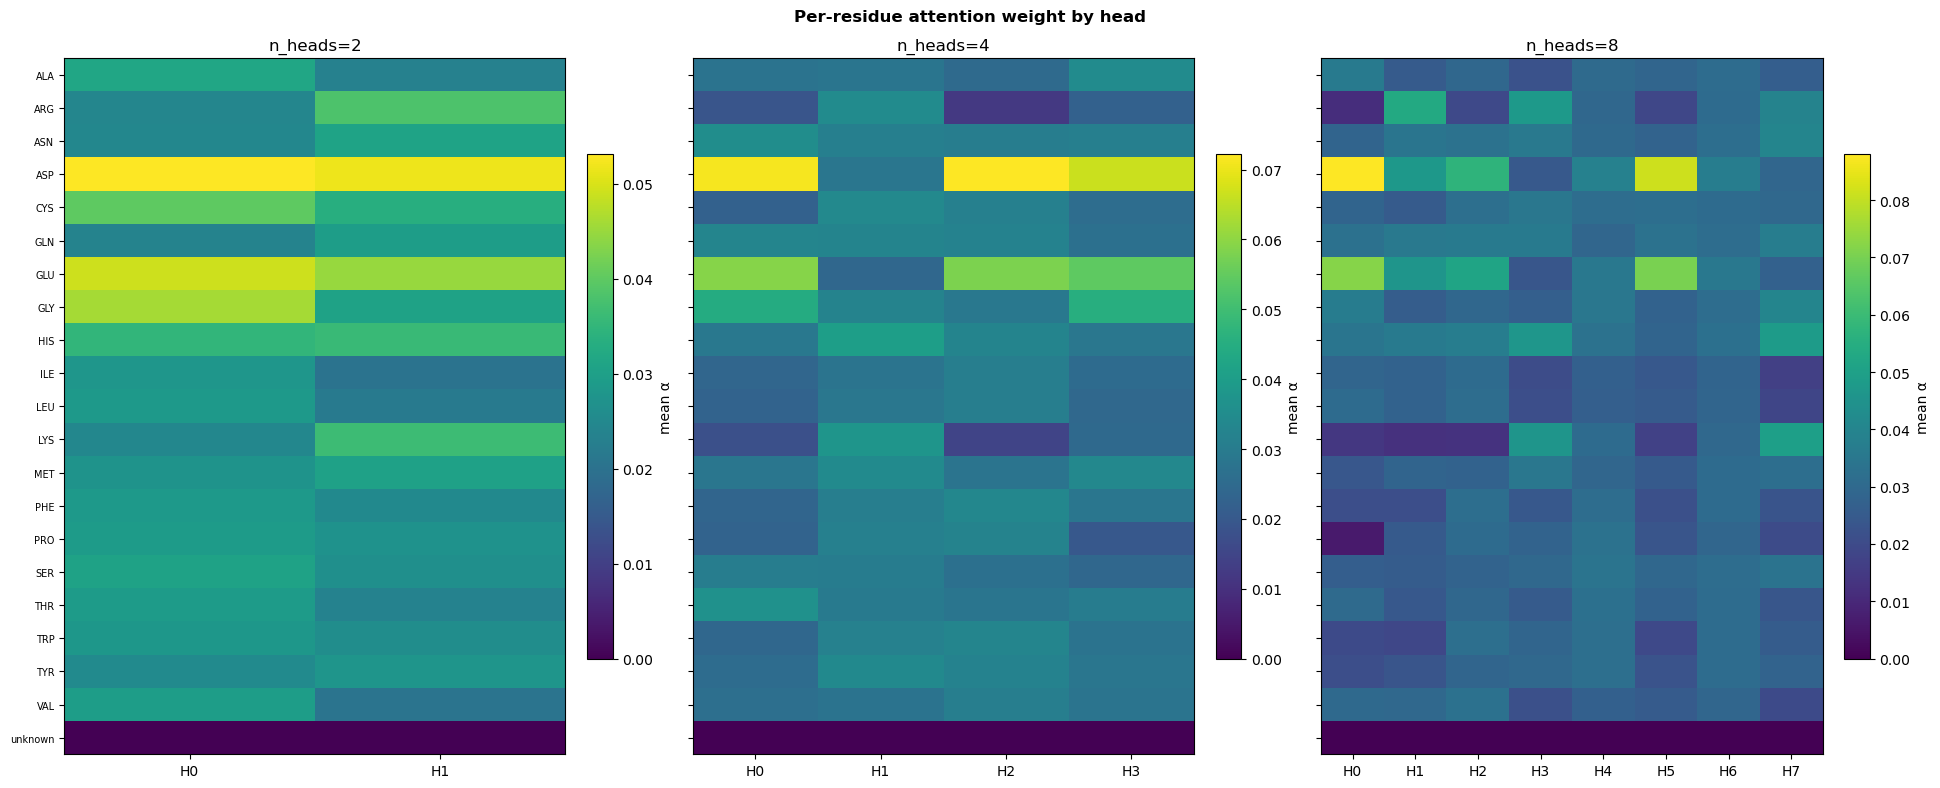

n_heads=2 — mean attention weight α by residue


,Head 0,Head 1,count
ALA,0.0315,0.0234,3965299
ARG,0.0245,0.0384,9331192
ASN,0.0245,0.0309,4350133
ASP,0.0531,0.0518,4643792
CYS,0.0399,0.0333,774049
GLN,0.0237,0.0296,5391378
GLU,0.0490,0.0449,7697272
GLY,0.0460,0.0305,2910940
HIS,0.0350,0.0360,2512689
ILE,0.0279,0.0203,3853917


n_heads=4 — mean attention weight α by residue


,Head 0,Head 1,Head 2,Head 3,count
ALA,0.0275,0.0280,0.0249,0.0348,3965299
ARG,0.0190,0.0350,0.0121,0.0225,9331192
ASN,0.0353,0.0310,0.0307,0.0310,4350133
ASP,0.0712,0.0284,0.0722,0.0663,4643792
CYS,0.0226,0.0341,0.0314,0.0260,774049
GLN,0.0328,0.0325,0.0320,0.0266,5391378
GLU,0.0590,0.0241,0.0580,0.0543,7697272
GLY,0.0445,0.0323,0.0288,0.0454,2910940
HIS,0.0288,0.0406,0.0327,0.0286,2512689
ILE,0.0238,0.0277,0.0309,0.0252,3853917


n_heads=8 — mean attention weight α by residue


,Head 0,Head 1,Head 2,Head 3,Head 4,Head 5,Head 6,Head 7,count
ALA,0.0363,0.0254,0.0296,0.0221,0.0306,0.0288,0.0310,0.0263,3965299
ARG,0.0115,0.0535,0.0196,0.0477,0.0294,0.0187,0.0309,0.0395,9331192
ASN,0.0285,0.0343,0.0332,0.0357,0.0302,0.0282,0.0319,0.0400,4350133
ASP,0.0880,0.0471,0.0573,0.0246,0.0387,0.0812,0.0373,0.0292,4643792
CYS,0.0285,0.0251,0.0321,0.0350,0.0314,0.0320,0.0309,0.0299,774049
GLN,0.0329,0.0357,0.0361,0.0360,0.0291,0.0331,0.0316,0.0372,5391378
GLU,0.0720,0.0459,0.0516,0.0235,0.0352,0.0705,0.0354,0.0275,7697272
GLY,0.0371,0.0260,0.0293,0.0268,0.0350,0.0277,0.0315,0.0399,2910940
HIS,0.0343,0.0361,0.0373,0.0461,0.0332,0.0283,0.0325,0.0484,2512689
ILE,0.0288,0.0277,0.0309,0.0206,0.0271,0.0243,0.0284,0.0167,3853917


In [12]:
# "unknown" is kept even when its count is 0, same reasoning as the per-element panel above.
residue_view = {}
for n_heads in available:
    stats = residue_stats[n_heads]
    present = [(name, stats[name]) for name in RESIDUE_NAMES
               if stats[name]["count"] > 0 or name == "unknown"]
    residue_view[n_heads] = {
        "names":  [p[0] for p in present],
        "means":  np.array([p[1]["mean"] for p in present]),   # (n_res, n_heads)
        "counts": [p[1]["count"] for p in present],
    }

fig, axes = plt.subplots(1, len(available), figsize=(6.5 * len(available), 8), sharey=True)
if len(available) == 1:
    axes = [axes]

for ax, n_heads in zip(axes, available):
    names = residue_view[n_heads]["names"]
    means = residue_view[n_heads]["means"]

    im = ax.imshow(means, aspect="auto", cmap="viridis")
    ax.set_yticks(range(len(names)))
    ax.set_yticklabels(names, fontsize=7)
    ax.set_xticks(range(n_heads))
    ax.set_xticklabels([f"H{h}" for h in range(n_heads)])
    ax.set_title(f"n_heads={n_heads}")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="mean α")

fig.suptitle("Per-residue attention weight by head", fontweight="bold")
fig.tight_layout()
plt.show()

for n_heads in available:
    view = residue_view[n_heads]
    df = pd.DataFrame(
        view["means"], index=view["names"],
        columns=[f"Head {h}" for h in range(n_heads)],
    ).round(4)
    df["count"] = view["counts"]
    print(f"n_heads={n_heads} — mean attention weight α by residue")
    display(df)


---
## 6. Specialization score — does more heads mean sharper differentiation?

For each head, take the standard deviation of its mean-α across elements — a head
attending uniformly regardless of element has low std; a head that strongly favors
certain elements has high std. Averaged across heads within a config, this gives one
specialization score per head-count config.

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


n_heads=2: per-head element-α std = [0.0175 0.0286]  (mean=0.0230)
n_heads=4: per-head element-α std = [0.0262 0.0276 0.0371 0.024 ]  (mean=0.0287)
n_heads=8: per-head element-α std = [0.0234 0.0309 0.0236 0.0277 0.0066 0.073  0.0057 0.0727]  (mean=0.0330)


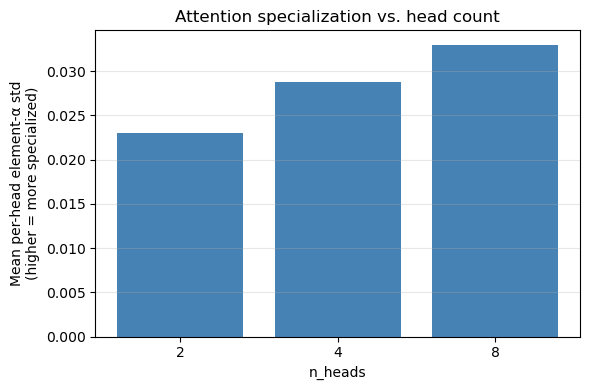

In [6]:
spec_scores = {}
for n_heads in available:
    stats = element_stats[n_heads]
    present = [stats[name]["mean"] for name in ELEMENT_NAMES if stats[name]["count"] > 0]
    means = np.array(present)   # (n_elem, n_heads)
    per_head_std = means.std(axis=0)   # (n_heads,)
    spec_scores[n_heads] = per_head_std
    print(f"n_heads={n_heads}: per-head element-α std = "
          f"{np.array2string(per_head_std, precision=4)}  (mean={per_head_std.mean():.4f})")

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar([str(n) for n in available], [spec_scores[n].mean() for n in available], color="steelblue")
ax.set_xlabel("n_heads")
ax.set_ylabel("Mean per-head element-α std\n(higher = more specialized)")
ax.set_title("Attention specialization vs. head count")
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
plt.show()


---
## 7. Electronegativity-weighted head affinity

A derived view not in the existing tooling: weight each head's per-element mean-α by
that element's Pauling electronegativity, giving one score per head — a head that
leans toward attending to electronegative atoms (O, N) scores high; a head leaning
toward electropositive/neutral atoms (H, C) scores low. `unknown` is excluded (no
well-defined electronegativity).

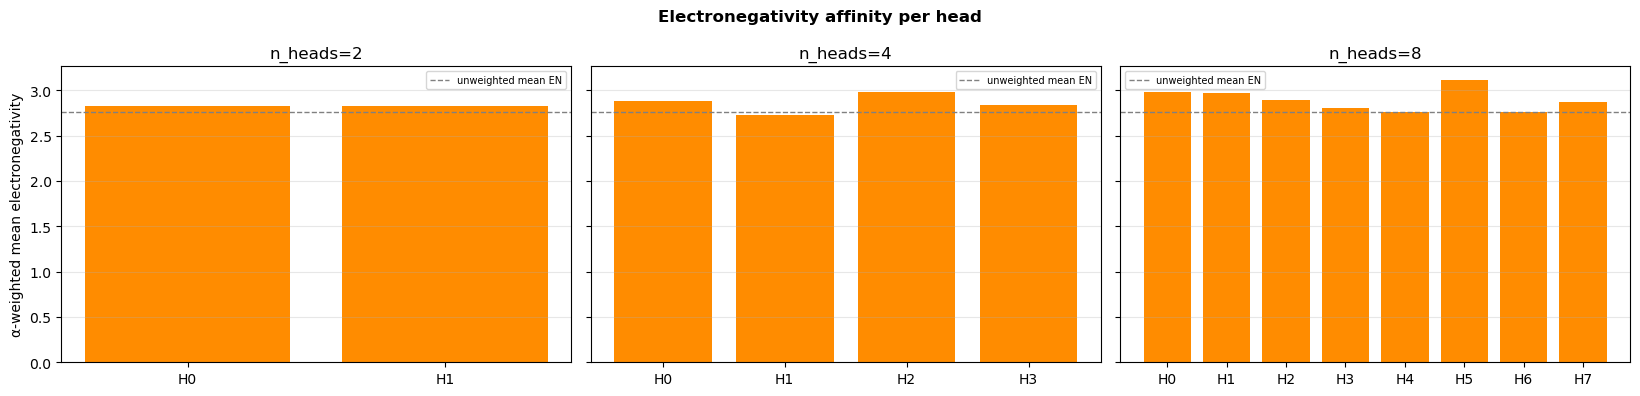

In [7]:
PAULING_ELECTRONEGATIVITY = {
    "H": 2.20, "C": 2.55, "N": 3.04, "O": 3.44, "S": 2.58,
}

fig, axes = plt.subplots(1, len(available), figsize=(5.5 * len(available), 4), sharey=True)
if len(available) == 1:
    axes = [axes]

for ax, n_heads in zip(axes, available):
    stats = element_stats[n_heads]
    # weighted mean electronegativity per head, weighted by that element's mean-alpha
    weighted = np.zeros(n_heads)
    weight_sum = np.zeros(n_heads)
    for name, en in PAULING_ELECTRONEGATIVITY.items():
        if stats[name]["count"] == 0:
            continue
        alpha = np.array(stats[name]["mean"])   # (n_heads,)
        weighted   += alpha * en
        weight_sum += alpha
    head_en = weighted / np.maximum(weight_sum, 1e-8)

    ax.bar(range(n_heads), head_en, color="darkorange")
    ax.axhline(np.mean(list(PAULING_ELECTRONEGATIVITY.values())), color="gray", ls="--", lw=1,
               label="unweighted mean EN")
    ax.set_xticks(range(n_heads))
    ax.set_xticklabels([f"H{h}" for h in range(n_heads)])
    ax.set_title(f"n_heads={n_heads}")
    ax.legend(fontsize=7)
    ax.grid(axis="y", alpha=0.3)

axes[0].set_ylabel("α-weighted mean electronegativity")
fig.suptitle("Electronegativity affinity per head", fontweight="bold")
fig.tight_layout()
plt.show()


---
## 8. Attention weight by residue classification group

The raw per-residue heatmap in section 5 is data-dense but hard to read as a story —
20 rows per panel. Grouping residues by the classic five-way side-chain classification
from `PROTEININFO.md` (nonpolar aliphatic, aromatic, polar uncharged, acidic, basic)
collapses that down to something a head-specialization claim can actually be checked
against: does a head lean acidic vs. basic, or aromatic vs. aliphatic? Each group's
mean α is the per-residue means weighted by how many atoms of that residue actually
appeared in the test set, so a 2-residue acidic group isn't drowned out by (or
artificially inflated relative to) a 7-residue nonpolar-aliphatic group.

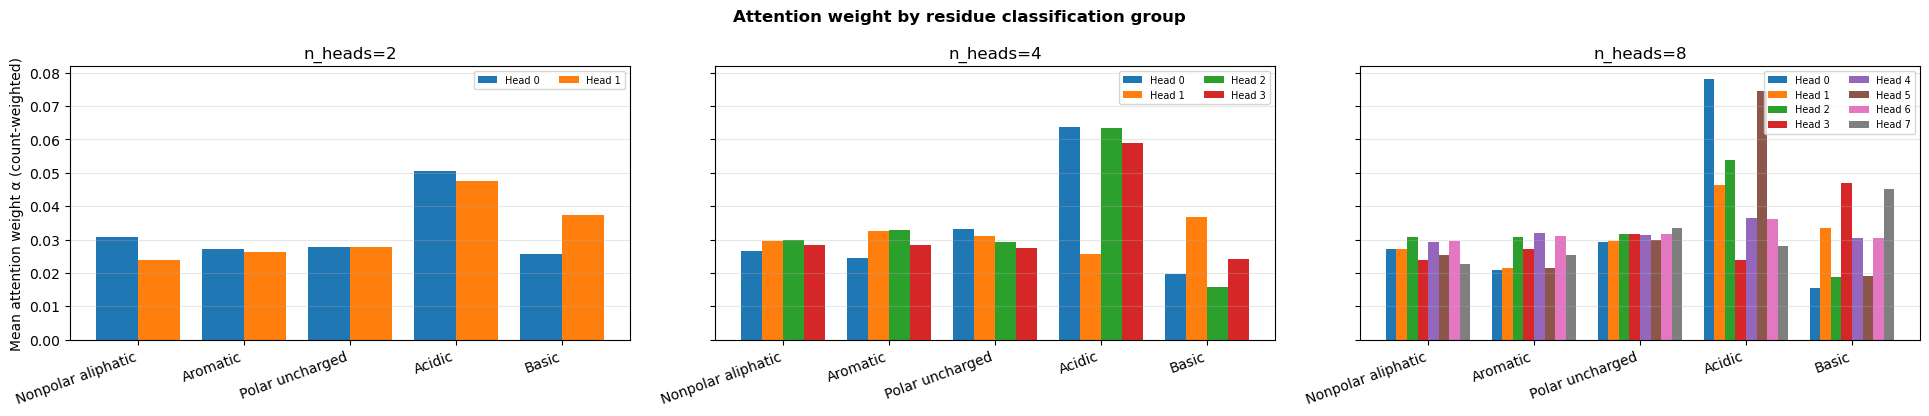

n_heads=2 — mean attention weight α by residue classification group


,Head 0,Head 1,count
Nonpolar aliphatic,0.0307,0.0240,30149175
Aromatic,0.0272,0.0264,7413221
Polar uncharged,0.0276,0.0278,21201944
Acidic,0.0506,0.0475,12341064
Basic,0.0258,0.0372,21133316


n_heads=4 — mean attention weight α by residue classification group


,Head 0,Head 1,Head 2,Head 3,count
Nonpolar aliphatic,0.0266,0.0295,0.0300,0.0282,30149175
Aromatic,0.0244,0.0324,0.0328,0.0283,7413221
Polar uncharged,0.0331,0.0309,0.0293,0.0276,21201944
Acidic,0.0636,0.0257,0.0634,0.0588,12341064
Basic,0.0195,0.0369,0.0157,0.0242,21133316


n_heads=8 — mean attention weight α by residue classification group


,Head 0,Head 1,Head 2,Head 3,Head 4,Head 5,Head 6,Head 7,count
Nonpolar aliphatic,0.0270,0.0270,0.0308,0.0239,0.0293,0.0255,0.0296,0.0227,30149175
Aromatic,0.0209,0.0216,0.0306,0.0272,0.0318,0.0215,0.0311,0.0254,7413221
Polar uncharged,0.0293,0.0296,0.0316,0.0318,0.0315,0.0299,0.0315,0.0335,21201944
Acidic,0.0780,0.0464,0.0537,0.0239,0.0365,0.0745,0.0361,0.0281,12341064
Basic,0.0155,0.0335,0.0187,0.0468,0.0305,0.0190,0.0306,0.0451,21133316


In [13]:
# Classic five-way side-chain classification, from PROTEININFO.md section 3.
RESIDUE_CLASS_GROUPS = {
    "Nonpolar aliphatic": ["GLY", "ALA", "VAL", "LEU", "ILE", "PRO", "MET"],
    "Aromatic":           ["PHE", "TRP", "TYR"],
    "Polar uncharged":    ["SER", "THR", "CYS", "ASN", "GLN"],
    "Acidic":             ["ASP", "GLU"],
    "Basic":              ["LYS", "ARG", "HIS"],
}

class_view = {}
for n_heads in available:
    stats = residue_stats[n_heads]
    group_names, group_means, group_counts = [], [], []
    for group, residues in RESIDUE_CLASS_GROUPS.items():
        counts = np.array([stats[r]["count"] for r in residues])
        means  = np.array([stats[r]["mean"] for r in residues])   # (n_res_in_group, n_heads)
        total  = counts.sum()
        group_names.append(group)
        group_means.append((means * counts[:, None]).sum(axis=0) / total)   # count-weighted
        group_counts.append(int(total))
    class_view[n_heads] = {
        "names":  group_names,
        "means":  np.array(group_means),   # (5, n_heads)
        "counts": group_counts,
    }

fig, axes = plt.subplots(1, len(available), figsize=(6.5 * len(available), 4.2), sharey=True)
if len(available) == 1:
    axes = [axes]

for ax, n_heads in zip(axes, available):
    names = class_view[n_heads]["names"]
    means = class_view[n_heads]["means"]

    x = np.arange(len(names))
    w = 0.8 / n_heads
    for h in range(n_heads):
        ax.bar(x + h * w - 0.4 + w / 2, means[:, h], width=w, label=f"Head {h}")
    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=20, ha="right")
    ax.set_title(f"n_heads={n_heads}")
    ax.legend(loc="upper right", fontsize=7, ncol=2)
    ax.grid(axis="y", alpha=0.3)

axes[0].set_ylabel("Mean attention weight α (count-weighted)")
fig.suptitle("Attention weight by residue classification group", fontweight="bold")
fig.tight_layout()
plt.show()

for n_heads in available:
    view = class_view[n_heads]
    df = pd.DataFrame(
        view["means"], index=view["names"],
        columns=[f"Head {h}" for h in range(n_heads)],
    ).round(4)
    df["count"] = view["counts"]
    print(f"n_heads={n_heads} — mean attention weight α by residue classification group")
    display(df)


---
## 9. Attention weight by residue exposure (buried vs. exposed)

A second grouping, orthogonal to side-chain chemistry: is a residue typically buried
in the hydrophobic core or exposed to solvent? `/home/student/thesis/outputs/residue_exposure.csv`
(`PROTEININFO.md` section 4) measured this directly from this project's own SES
meshes across all 8,461 proteins — each residue type's `frac_buried` there is the
fraction of its instances with relative solvent accessibility below the standard 25%
cutoff. Residues with `frac_buried > 0.5` are labelled buried-majority here
(expected: LEU, VAL, CYS, ILE, TRP, PHE); everything else is exposed-majority.

This is the grouping most directly relevant to the modeling task: ESP at the query
surface is generated almost entirely by exposed charge, so a head that systematically
up-weights exposed residues would be doing something functionally sensible rather
than just picking up on residue identity for its own sake.

The history saving thread hit an unexpected error (OperationalError('database or disk is full')).History will not be written to the database.
Buried-majority (>50% of instances buried): ['TRP', 'PHE', 'LEU', 'VAL', 'CYS', 'ILE']
Exposed-majority: ['ARG', 'LYS', 'GLN', 'PRO', 'ASN', 'HIS', 'SER', 'GLU', 'THR', 'ASP', 'GLY', 'TYR', 'ALA', 'MET']


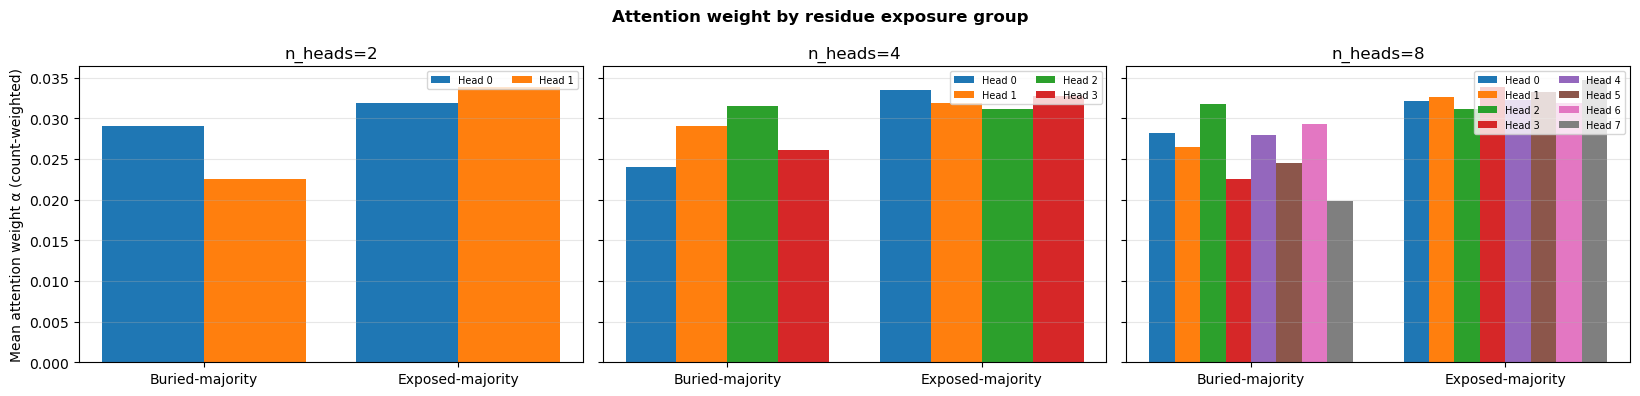

n_heads=2 — mean attention weight α by exposure group


,Head 0,Head 1,count
Buried-majority,0.0290,0.0225,21206358
Exposed-majority,0.0319,0.0339,71032362


n_heads=4 — mean attention weight α by exposure group


,Head 0,Head 1,Head 2,Head 3,count
Buried-majority,0.0240,0.0290,0.0315,0.0261,21206358
Exposed-majority,0.0334,0.0319,0.0312,0.0328,71032362


n_heads=8 — mean attention weight α by exposure group


,Head 0,Head 1,Head 2,Head 3,Head 4,Head 5,Head 6,Head 7,count
Buried-majority,0.0281,0.0265,0.0318,0.0225,0.0280,0.0245,0.0293,0.0198,21206358
Exposed-majority,0.0322,0.0327,0.0311,0.0339,0.0322,0.0333,0.0318,0.0347,71032362


In [14]:
exposure_df = pd.read_csv(Path("/home/student/thesis/outputs/residue_exposure.csv").resolve()).set_index("residue")
BURIED_MAJORITY  = exposure_df.index[exposure_df["frac_buried"] > 0.5].tolist()
EXPOSED_MAJORITY = exposure_df.index[exposure_df["frac_buried"] <= 0.5].tolist()
print("Buried-majority (>50% of instances buried):", BURIED_MAJORITY)
print("Exposed-majority:", EXPOSED_MAJORITY)

RESIDUE_EXPOSURE_GROUPS = {
    "Buried-majority":  BURIED_MAJORITY,
    "Exposed-majority": EXPOSED_MAJORITY,
}

exposure_view = {}
for n_heads in available:
    stats = residue_stats[n_heads]
    group_names, group_means, group_counts = [], [], []
    for group, residues in RESIDUE_EXPOSURE_GROUPS.items():
        residues = [r for r in residues if stats[r]["count"] > 0]
        counts = np.array([stats[r]["count"] for r in residues])
        means  = np.array([stats[r]["mean"] for r in residues])   # (n_res_in_group, n_heads)
        total  = counts.sum()
        group_names.append(group)
        group_means.append((means * counts[:, None]).sum(axis=0) / total)   # count-weighted
        group_counts.append(int(total))
    exposure_view[n_heads] = {
        "names":  group_names,
        "means":  np.array(group_means),   # (2, n_heads)
        "counts": group_counts,
    }

fig, axes = plt.subplots(1, len(available), figsize=(5.5 * len(available), 4), sharey=True)
if len(available) == 1:
    axes = [axes]

for ax, n_heads in zip(axes, available):
    names = exposure_view[n_heads]["names"]
    means = exposure_view[n_heads]["means"]

    x = np.arange(len(names))
    w = 0.8 / n_heads
    for h in range(n_heads):
        ax.bar(x + h * w - 0.4 + w / 2, means[:, h], width=w, label=f"Head {h}")
    ax.set_xticks(x)
    ax.set_xticklabels(names)
    ax.set_title(f"n_heads={n_heads}")
    ax.legend(loc="upper right", fontsize=7, ncol=2)
    ax.grid(axis="y", alpha=0.3)

axes[0].set_ylabel("Mean attention weight α (count-weighted)")
fig.suptitle("Attention weight by residue exposure group", fontweight="bold")
fig.tight_layout()
plt.show()

for n_heads in available:
    view = exposure_view[n_heads]
    df = pd.DataFrame(
        view["means"], index=view["names"],
        columns=[f"Head {h}" for h in range(n_heads)],
    ).round(4)
    df["count"] = view["counts"]
    print(f"n_heads={n_heads} — mean attention weight α by exposure group")
    display(df)


---
## 11. Emergent residue groupings from attention alone (no chemistry labels used)

Sections 8–9 imposed groupings we already believed in (side-chain classification,
measured exposure) onto the attention data and asked whether the pattern lined up.
This section inverts that: cluster the 20 standard residues purely from their
attention-weight profile across heads — the same per-residue means behind section 5's
heatmap, z-scored per head so no single head's raw scale dominates the distance — and
see what groups the model itself has implicitly formed, with no chemistry vocabulary
anywhere in the loop. Probing what a trained attention mechanism has organized
internally, purely from its own weights, is a standard move in transformer
interpretability (Clark et al. 2019, "What Does BERT Look At? An Analysis of BERT's
Attention"; Michel, Levy & Neubig 2019, "Are Sixteen Heads Really Better than One?") —
applied here to a geometric GNN's atom→query cross-attention rather than a language
model's self-attention.

Hierarchical (agglomerative) clustering gives a dendrogram: residues that merge low
(short cluster distance) have near-identical attention fingerprints across heads;
residues that only merge at the top are attended to completely differently. Cutting
the tree at 5 clusters — matching the classic chemistry-class count from section 8 —
gives a concrete, inspectable grouping to read by eye before section 12 checks it
quantitatively.

In [ ]:
from scipy.cluster.hierarchy import dendrogram, fcluster, linkage

STANDARD_RESIDUES = [r for r in RESIDUE_NAMES if r != "unknown"]

cluster_data = {}
for n_heads in available:
    stats = residue_stats[n_heads]
    profile = np.array([stats[r]["mean"] for r in STANDARD_RESIDUES])   # (20, n_heads)
    # z-score each head's column so a head with a larger raw-α range doesn't
    # dominate the distance metric purely on scale, not on shape
    z = (profile - profile.mean(axis=0)) / profile.std(axis=0)
    cluster_data[n_heads] = {"profile": profile, "z": z, "linkage": linkage(z, method="average")}

fig, axes = plt.subplots(1, len(available), figsize=(6.5 * len(available), 5.5))
if len(available) == 1:
    axes = [axes]

for ax, n_heads in zip(axes, available):
    dendrogram(
        cluster_data[n_heads]["linkage"], labels=STANDARD_RESIDUES,
        ax=ax, leaf_rotation=90, leaf_font_size=8,
        color_threshold=0, above_threshold_color="steelblue",
    )
    ax.set_title(f"n_heads={n_heads}")
    ax.set_ylabel("Cluster distance (z-scored attention profile)")

fig.suptitle("Emergent residue grouping from attention profile alone — no chemistry labels used", fontweight="bold")
fig.tight_layout()
plt.show()

for n_heads in available:
    emergent5 = fcluster(cluster_data[n_heads]["linkage"], t=5, criterion="maxclust")
    print(f"n_heads={n_heads} — emergent 5-way clusters (cut to match the classic chemistry-class count):")
    for c in sorted(set(emergent5)):
        members = [STANDARD_RESIDUES[i] for i in range(len(STANDARD_RESIDUES)) if emergent5[i] == c]
        print(f"  cluster {c}: {members}")
    print()


---
## 12. Does the emergent grouping mean anything? (quantitative agreement)

Eyeballing a dendrogram against known chemistry is exactly the kind of thing that's
easy to convince yourself of either way. Adjusted Rand Index (ARI) and normalized
mutual information (NMI) give an actual number instead: **ARI ≈ 0** means the
attention-only clusters agree with a known grouping no better than a random partition
of the same cluster sizes would; **ARI ≈ 1** means the clusters exactly recover it.
Compared against three independent known groupings — the section 8 chemistry class,
the section 9 exposure split, and simple charge sign — for each head-count config.

If these numbers come back near zero across the board, that *is* the answer to "what
is the model grouping and why": not by any chemistry vocabulary a human would reach
for. That would be a legitimate, reportable negative result — the RBF geometric bias
term and the training loss never see chemistry labels, so there's no a priori reason
attention weights *must* organize around textbook classifications rather than around
something purely geometric (local packing density, atom degree, edge-length
distribution) that happens to correlate weakly, or not at all, with any human category.

In [ ]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

chem_group_of     = {r: g for g, rs in RESIDUE_CLASS_GROUPS.items() for r in rs}
exposure_group_of = {r: g for g, rs in RESIDUE_EXPOSURE_GROUPS.items() for r in rs}
CHARGE_GROUP_OF = {
    **{r: "acidic" for r in ["ASP", "GLU"]},
    **{r: "basic"  for r in ["LYS", "ARG", "HIS"]},
}

comparisons = [
    ("5-way chemistry class (section 8)",   5, [chem_group_of[r] for r in STANDARD_RESIDUES]),
    ("buried/exposed majority (section 9)", 2, [exposure_group_of[r] for r in STANDARD_RESIDUES]),
    ("charge sign (acidic/basic/neutral)",  3, [CHARGE_GROUP_OF.get(r, "neutral") for r in STANDARD_RESIDUES]),
]

agreement_rows = []
for n_heads in available:
    Z = cluster_data[n_heads]["linkage"]
    for label_name, k, true_labels in comparisons:
        emergent = fcluster(Z, t=k, criterion="maxclust")
        agreement_rows.append({
            "n_heads":     n_heads,
            "compared_to": label_name,
            "k":           k,
            "ARI":         adjusted_rand_score(true_labels, emergent),
            "NMI":         normalized_mutual_info_score(true_labels, emergent),
        })

agreement_df = pd.DataFrame(agreement_rows)
display(agreement_df.round(3))

fig, ax = plt.subplots(figsize=(7, 4))
pivot = agreement_df.pivot(index="compared_to", columns="n_heads", values="ARI")
pivot.plot(kind="bar", ax=ax)
ax.axhline(0, color="black", lw=0.8)
ax.set_ylabel("Adjusted Rand Index\n(0 = chance agreement, 1 = perfect recovery)")
ax.set_title("Do attention-only clusters recover known residue groupings?")
ax.legend(title="n_heads")
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
plt.show()


---
## 13. Decision

*Fill in once reviewed.*

| n_heads | Most electronegative-leaning head | Most specialized head | Overall specialization (mean std) | Most acidic/basic-leaning head | Most exposed-leaning head | ARI vs. chemistry class (k=5) | ARI vs. exposure (k=2) |
|---|---|---|---|---|---|---|---|
| 2 | ? | ? | ? | ? | ? | ? | ? |
| 4 | ? | ? | ? | ? | ? | ? | ? |
| 8 | ? | ? | ? | ? | ? | ? | ? |

**Reasoning:** *does head specialization sharpen with more heads, or does it stay
diffuse regardless of count? Does any head's electronegativity affinity line up with
a chemically sensible story (e.g. one head consistently favoring O/N)? How does the
per-head story in sections 4–7 relate to the raw performance gap in section 2 — does
`n_heads=4`'s test-score edge track a specific behavioral difference, or does it look
like noise? Do the classification-group (section 8) and exposure-group (section 9)
views sharpen the electronegativity/specialization story from sections 6–7, or
contradict it?*

*And the section 11–12 question, which is the real test of all of the above: when the*
*residues are clustered from their raw attention profile alone, with zero chemistry*
*vocabulary supplied, do the resulting groups look like section 8's chemistry classes,*
*section 9's exposure split, or neither? If the ARI/NMI numbers are near zero across*
*every head count, the honest conclusion is that sections 4–9 were finding real but*
*shallow correlations — human-legible groupings that a determined analyst can always*
*find some alignment with — rather than evidence the model has internalized anything*
*resembling a chemistry taxonomy. That's not a failure of the notebook; it's the*
*actual answer to "what is the model grouping and why," and worth stating plainly in*
*the thesis either way.*